In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm

In [2]:
# generate a noise / signal / RFI data matrix in the style of the RFI project
# (complex baseband, dB-parameterised power, CPI blocks, multi-band Doppler RFI)

from dataclasses import dataclass
from typing import List

# ---- configuration -------------------------------------------------------
TOTAL_PULSES = 16      # rows  -> the "pulse" axis (one CPI)
RANGE_BINS   = 250     # cols  -> range bins

NOISE_DB     = 0.0     # thermal noise power (dB)
SNR_DB       = 10.0    # signal power above noise (dB)

# One block == one CPI, so a CPI receives MIN_BANDS..MAX_BANDS emitters total
# (NOT per sub-block). Each emitter occupies its own pulse row, so the number
# of RFI eigenvalues == the number of emitters.
BLOCK_HEIGHT = TOTAL_PULSES               # pulses per CPI block
N_BLOCKS     = TOTAL_PULSES // BLOCK_HEIGHT   # = 1
MIN_BANDS, MAX_BANDS = 1, 6               # RFI emitters injected per CPI
JNR_RANGE_DB = (10, 30)                   # per-band jammer-to-noise ratio (dB)

# independent RNG streams so each component is reproducible and uncorrelated
NOISE_SEED, SIGNAL_SEED, RFI_SEED, JNR_SEED = 1, 2, 3, 4


@dataclass
class BandMeta:
    local_idx: int
    row: int
    jnr_db: int


@dataclass
class RfiMeta:
    bands_per_block: List[List[BandMeta]]


def generate_clean_image(seed=0):
    """Spatially white complex noise + signal (NOISE_DB and NOISE_DB + SNR_DB)."""
    noise_power_linear  = 10.0 ** (NOISE_DB / 10.0)
    signal_power_linear = noise_power_linear * (10.0 ** (SNR_DB / 10.0))

    # complex Gaussian: real and imag each carry half the power
    rng_noise = np.random.default_rng(seed + NOISE_SEED)
    noise_matrix = (
        rng_noise.standard_normal((TOTAL_PULSES, RANGE_BINS))
        + 1j * rng_noise.standard_normal((TOTAL_PULSES, RANGE_BINS))
    ) * np.sqrt(noise_power_linear / 2.0)

    rng_signal = np.random.default_rng(seed + SIGNAL_SEED)
    signal_matrix = (
        rng_signal.standard_normal((TOTAL_PULSES, RANGE_BINS))
        + 1j * rng_signal.standard_normal((TOTAL_PULSES, RANGE_BINS))
    ) * np.sqrt(signal_power_linear / 2.0)

    return (noise_matrix + signal_matrix).astype(np.complex64)


def _generate_multi_band_rfi(seed):
    """Inject MIN_BANDS..MAX_BANDS uncorrelated Doppler RFI emitters per CPI.

    Each emitter lands on its OWN pulse row (sampled without replacement) so
    that one emitter == one contaminated pulse == one RFI eigenvalue. Each
    draws its own JNR and is generated from an independent child RNG stream,
    so no two emitters share any RNG state.
    """
    noise_power_linear = 10.0 ** (NOISE_DB / 10.0)

    rng_struct = np.random.default_rng(seed + RFI_SEED)   # n_bands + row placement
    rng_jnr    = np.random.default_rng(seed + JNR_SEED)   # per-band JNR draws

    rfi_matrix = np.zeros((TOTAL_PULSES, RANGE_BINS), dtype=np.complex64)
    bands_per_block: List[List[BandMeta]] = []

    for b in range(N_BLOCKS):
        block_start = b * BLOCK_HEIGHT
        n_bands       = int(rng_struct.integers(MIN_BANDS, MAX_BANDS + 1))
        # distinct rows -> emitters map 1:1 onto RFI eigenvalues
        local_indices = rng_struct.choice(BLOCK_HEIGHT, size=n_bands, replace=False)

        block_bands: List[BandMeta] = []
        for band_idx in range(n_bands):
            local_idx = int(local_indices[band_idx])
            abs_row   = block_start + local_idx

            jnr_db           = int(rng_jnr.integers(JNR_RANGE_DB[0], JNR_RANGE_DB[1] + 1))
            rfi_power_linear = noise_power_linear * (10.0 ** (jnr_db / 10.0))
            sigma            = np.sqrt(rfi_power_linear / 2.0)

            # deterministic per-band child stream -> fully reproducible, uncorrelated
            child_seed = (seed + RFI_SEED) * 10_000 + b * MAX_BANDS + band_idx
            rng_band   = np.random.default_rng(child_seed)

            doppler_freq = rng_band.uniform(-0.5, 0.5)
            range_coeff  = (
                rng_band.standard_normal(RANGE_BINS)
                + 1j * rng_band.standard_normal(RANGE_BINS)
            ) * sigma

            phase = np.exp(1j * 2.0 * np.pi * doppler_freq * abs_row)
            rfi_matrix[abs_row, :] += (phase * range_coeff).astype(np.complex64)
            block_bands.append(BandMeta(local_idx=local_idx, row=abs_row, jnr_db=jnr_db))

        bands_per_block.append(block_bands)

    return rfi_matrix, RfiMeta(bands_per_block=bands_per_block)


def generate_rfi_image(seed=0):
    """Clean image (noise + signal) with additive multi-band RFI injected."""
    clean_image      = generate_clean_image(seed)
    rfi_signal, meta = _generate_multi_band_rfi(seed)
    return (clean_image + rfi_signal).astype(np.complex64), meta


# ---- build the complex data matrix --------------------------------------
matrix, meta = generate_rfi_image(seed=0)

for b, bands in enumerate(meta.bands_per_block):
    print(f"block {b}: RFI rows {[bm.row for bm in bands]}  "
          f"JNR(dB) {[bm.jnr_db for bm in bands]}")


block 0: RFI rows [2, 14, 1, 3, 12]  JNR(dB) [25, 29, 28, 20, 29]


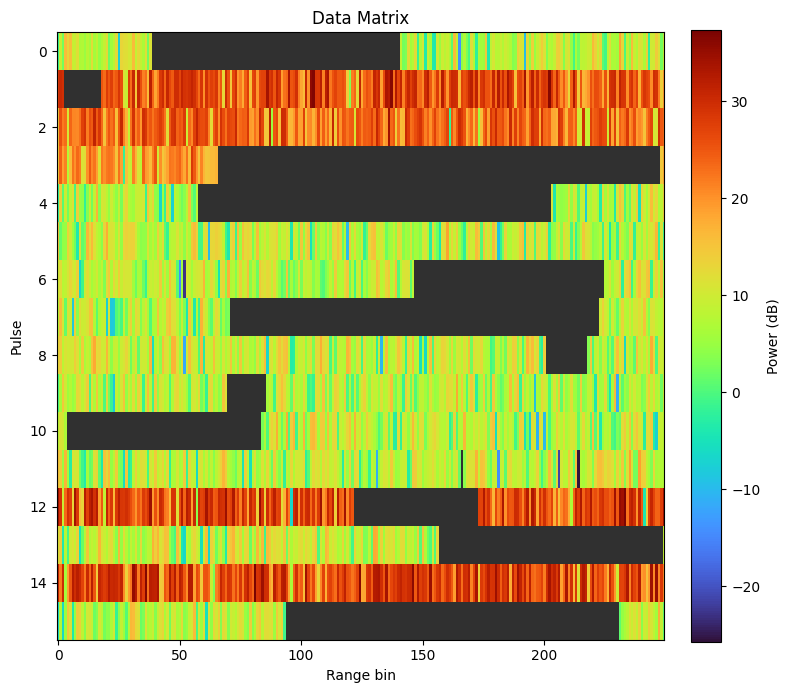

In [3]:
# zero out random chunks of items in a row (gaps / dropouts)

gap_rng = np.random.default_rng(0)
for row in matrix:
    is_invalid = gap_rng.choice([True, False], size=1, p=[0.7, 0.3])
    num_invalids = gap_rng.integers(0, 200)

    if is_invalid:
        # block out one contiguous section of invalid items in the row
        start_index = gap_rng.integers(0, RANGE_BINS - num_invalids)
        row[start_index:start_index + num_invalids] = 0

# plot the data matrix as power in dB; gaps (zeros) render as blank cells
mag = np.abs(matrix)
power_db = np.full(mag.shape, np.nan)          # gaps stay NaN -> shown as "bad"
np.log10(mag, out=power_db, where=mag > 0)
power_db *= 20.0                               # 20*log10(|x|) = power in dB

cmap = plt.get_cmap("turbo").copy()
cmap.set_bad("#303030")                        # colour used for the gaps

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(power_db, cmap=cmap, interpolation="nearest", aspect="auto")
ax.set_box_aspect(1)                           # square data area despite 16x250 shape
fig.colorbar(im, ax=ax, label="Power (dB)", fraction=0.046, pad=0.04)
ax.set_title("Data Matrix")
ax.set_xlabel("Range bin")
ax.set_ylabel("Pulse")
plt.tight_layout()
plt.show()


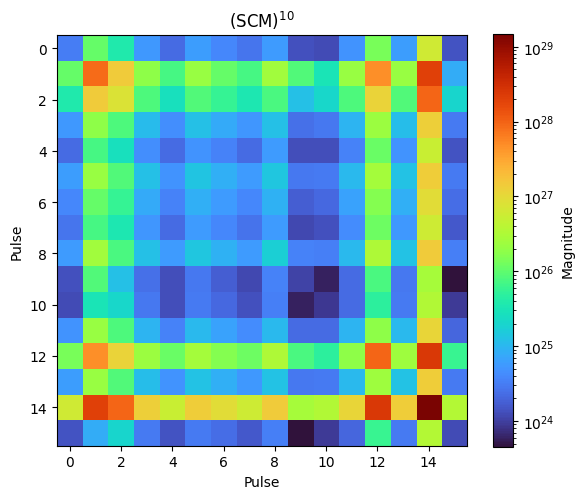

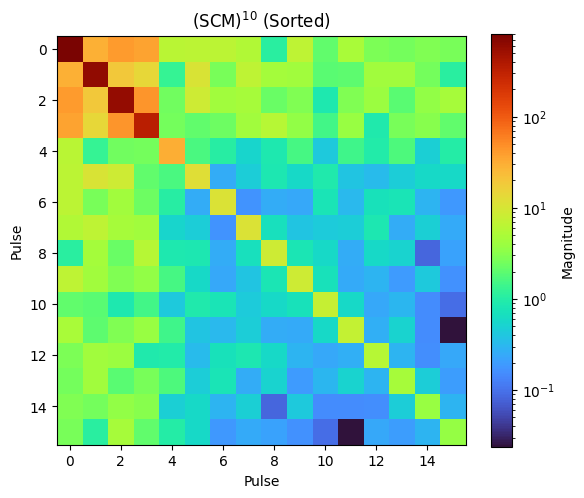

In [4]:
# sample covariance matrix across pulses: M M^H / RANGE_BINS
# (conjugate transpose because the data is complex-valued)

scm = (matrix @ matrix.conj().T) / RANGE_BINS

power = np.linalg.matrix_power(scm, 10)

plt.figure(figsize=(6, 5))
plt.imshow(
    np.abs(power),
    cmap="turbo",
    interpolation="nearest",
    norm=LogNorm()
)
plt.colorbar(label="Magnitude")
plt.title(r"$(\mathrm{SCM})^{10}$")
plt.xlabel("Pulse")
plt.ylabel("Pulse")
plt.tight_layout()
plt.show()


# order the diagonal (pulse powers) in descending order and re-plot.
# the diagonal of a Hermitian SCM is real, so take .real before sorting.
diagonal = np.diag(scm).real
sorted_indices = np.argsort(diagonal)[::-1]
sorted_scm = scm[sorted_indices, :][:, sorted_indices]

plt.figure(figsize=(6, 5))
plt.imshow(
    np.abs(sorted_scm),
    cmap="turbo",
    interpolation="nearest",
    norm=LogNorm()
)
plt.colorbar(label="Magnitude")
plt.title(r"$(\mathrm{SCM})^{10}$ (Sorted)")
plt.xlabel("Pulse")
plt.ylabel("Pulse")
plt.tight_layout()
plt.show()


In [5]:
# ---- assemble a full image from a 3x3 grid of CPI blocks -----------------
# full image = (GRID*TOTAL_PULSES) x (GRID*RANGE_BINS) = 48 x 750

GRID = 3
CPI_ROWS, CPI_COLS   = TOTAL_PULSES, RANGE_BINS          # 16 x 250 per CPI
full_rows, full_cols = GRID * CPI_ROWS, GRID * CPI_COLS  # 48 x 750

# a pulse row needs at least this many non-zero samples to be usable as a set
# of covariance snapshots (Reed-Mallett-Brennan rule of thumb: ~2N snapshots)
MIN_VALID_SAMPLES = 2 * TOTAL_PULSES                     # = 32

full_image = np.zeros((full_rows, full_cols), dtype=np.complex64)

def block_view(bi, bj):
    """Return a writable view of CPI block (bi, bj) inside the full image."""
    r0, c0 = bi * CPI_ROWS, bj * CPI_COLS
    return full_image[r0:r0 + CPI_ROWS, c0:c0 + CPI_COLS]

# 1. fill each block with an independent noise / signal / RFI CPI, keeping the
#    generator metadata so we know which pulses actually carry RFI
cpi_rfi_rows = {}
for bi in range(GRID):
    for bj in range(GRID):
        cpi, meta_ij = generate_rfi_image(seed=bi * GRID + bj)
        block_view(bi, bj)[:] = cpi
        cpi_rfi_rows[(bi, bj)] = {bm.row for blk in meta_ij.bands_per_block for bm in blk}

# 2. apply gaps (data dropouts) within every CPI
gap_rng = np.random.default_rng(0)

def apply_gaps(cpi):
    for row in cpi:
        if gap_rng.choice([True, False], p=[0.7, 0.3]):
            n = int(gap_rng.integers(0, 200))
            start = int(gap_rng.integers(0, RANGE_BINS - n)) if n else 0
            row[start:start + n] = 0

for bi in range(GRID):
    for bj in range(GRID):
        apply_gaps(block_view(bi, bj))

# 3. force the MIDDLE CPI to be invalid: wipe two pulse rows so they fall
#    far below MIN_VALID_SAMPLES (here fully dead -> 0 valid samples), i.e.
#    at least one row no longer has enough samples to estimate a covariance
mid = block_view(GRID // 2, GRID // 2)
for dead_row in (5, 11):
    mid[dead_row, :] = 0

# 4. validity check: a CPI is invalid if ANY pulse row has too few valid samples
def cpi_validity(cpi):
    valid_per_row = np.count_nonzero(cpi, axis=1)
    return np.all(valid_per_row >= MIN_VALID_SAMPLES), valid_per_row

invalid_blocks = []
print(f"MIN_VALID_SAMPLES = {MIN_VALID_SAMPLES}")
for bi in range(GRID):
    for bj in range(GRID):
        ok, vpr = cpi_validity(block_view(bi, bj))
        if not ok:
            invalid_blocks.append((bi, bj))
        print(f"  CPI ({bi},{bj}) {'OK     ' if ok else 'INVALID'}"
              f"  min valid samples/row = {vpr.min():3d}")
print("invalid CPIs:", invalid_blocks)

# 5. n_rfi = pulses that are ACTUALLY contaminated. A fully wiped pulse holds
#    no data, so none of its samples are RFI-affected -> it drops out.
#    knee = 1-based index of the FIRST NON-RFI eigenvalue = n_rfi + 1, e.g.
#    3 effective emitters -> eigenvalues 1..3 are RFI, so the knee is at 4.
n_rfi, knee = {}, {}
print(f"\n{'CPI':8s} {'RFI pulses (injected)':26s} {'wiped':8s} {'n_rfi':>5s} {'knee':>5s}")
for bi in range(GRID):
    for bj in range(GRID):
        rfi_rows = cpi_rfi_rows[(bi, bj)]
        alive = set(np.flatnonzero(np.count_nonzero(block_view(bi, bj), axis=1) > 0).tolist())
        effective = rfi_rows & alive            # contaminated AND still has data
        wiped     = sorted(rfi_rows - alive)    # RFI pulses destroyed by the gaps
        n_rfi[(bi, bj)] = len(effective)
        knee[(bi, bj)]  = len(effective) + 1    # first clean eigenvalue (1-based)
        print(f"({bi},{bj})    {str(sorted(rfi_rows)):26s} {str(wiped):8s} "
              f"{n_rfi[(bi,bj)]:5d} {knee[(bi,bj)]:5d}")


MIN_VALID_SAMPLES = 32
  CPI (0,0) OK       min valid samples/row =  56
  CPI (0,1) OK       min valid samples/row =  60
  CPI (0,2) OK       min valid samples/row =  51
  CPI (1,0) OK       min valid samples/row = 147
  CPI (1,1) INVALID  min valid samples/row =   0
  CPI (1,2) OK       min valid samples/row =  54
  CPI (2,0) OK       min valid samples/row = 108
  CPI (2,1) OK       min valid samples/row =  57
  CPI (2,2) OK       min valid samples/row =  53
invalid CPIs: [(1, 1)]

CPI      RFI pulses (injected)      wiped    n_rfi  knee
(0,0)    [1, 2, 3, 12, 14]          []           5     6
(0,1)    [7, 11, 12, 14, 15]        []           5     6
(0,2)    [0, 7, 8, 9, 11]           []           5     6
(1,0)    [5, 7, 14]                 []           3     4
(1,1)    [6, 8, 11, 13, 14, 15]     [11]         5     6
(1,2)    [2, 3, 5, 12, 13]          []           5     6
(2,0)    [4, 12, 14]                []           3     4
(2,1)    [2, 3, 11, 13, 14]         []           5     6

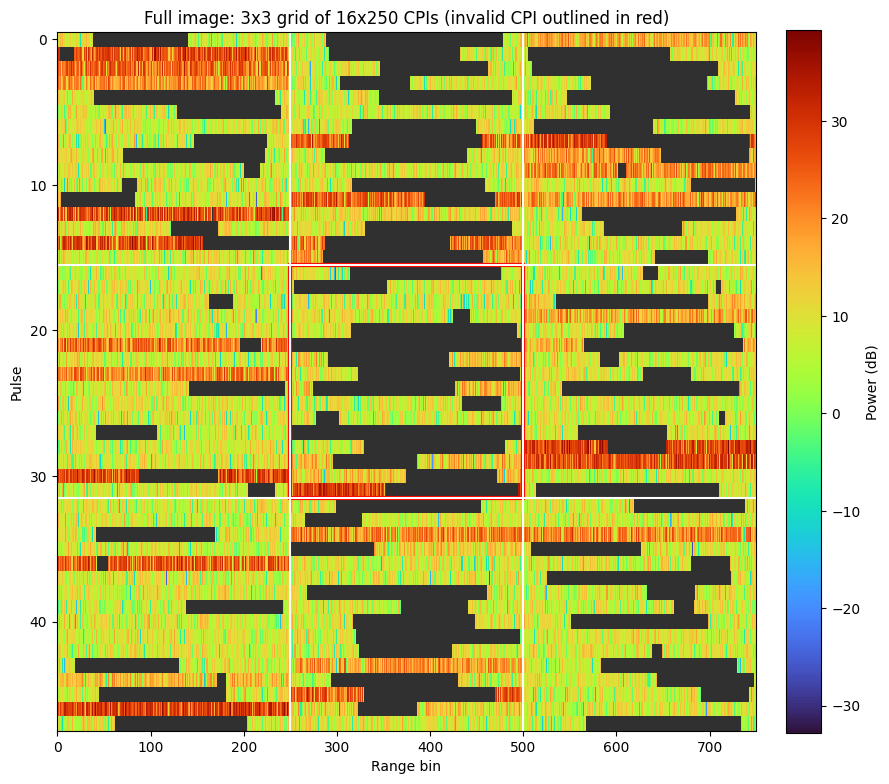

In [6]:
# ---- plot the full image (square) with CPI grid + invalid CPI outlined ----
mag = np.abs(full_image)
power_db = np.full(mag.shape, np.nan)     # gaps stay NaN -> shown as "bad"
np.log10(mag, out=power_db, where=mag > 0)
power_db *= 20.0                          # 20*log10(|x|) = power in dB

cmap = plt.get_cmap("turbo").copy()
cmap.set_bad("#303030")

fig, ax = plt.subplots(figsize=(9, 9))
im = ax.imshow(power_db, cmap=cmap, interpolation="nearest", aspect="auto")
ax.set_box_aspect(1)                      # square, so the pulse axis isn't compressed

# CPI boundaries
for k in range(1, GRID):
    ax.axhline(k * CPI_ROWS - 0.5, color="white", lw=1.5)
    ax.axvline(k * CPI_COLS - 0.5, color="white", lw=1.5)

# outline every invalid CPI in red
for (bi, bj) in invalid_blocks:
    ax.add_patch(mpatches.Rectangle(
        (bj * CPI_COLS - 0.5, bi * CPI_ROWS - 0.5), CPI_COLS, CPI_ROWS,
        fill=False, edgecolor="red", lw=3))

fig.colorbar(im, ax=ax, label="Power (dB)", fraction=0.046, pad=0.04)
ax.set_title("Full image: 3x3 grid of 16x250 CPIs (invalid CPI outlined in red)")
ax.set_xlabel("Range bin")
ax.set_ylabel("Pulse")
plt.tight_layout()
plt.show()


In [7]:
# ---- Method 1 (diagonal-only): robust available-case per-pulse power ------
# The SCM here is ~diagonal (off-diagonal energy is only a few % of the
# diagonal), so the eigenvalue profile == the sorted diagonal. We therefore
# skip the full SCM and repair only the diagonal:
#   * robust (median) power from each pulse's OWN valid samples
#   * dead pulses -> the CPI's bulk power (an independent noise floor)
#   * + light diagonal loading so every value is strictly positive (full rank)
# No missing sample is ever filled from another pulse -> no fabricated
# cross-pulse correlation, and >= 12 non-zero eigenvalues are guaranteed.

MIN_ROBUST = 4        # need >= this many valid samples for a robust row estimate
LOAD_FRAC  = 0.03     # diagonal loading = 3% of bulk power

def naive_diagonal(cpi):
    """Diagonal the naive way: mean |x|^2 over ALL bins (gaps counted as zeros)."""
    return np.mean(np.abs(cpi) ** 2, axis=1)

def robust_diagonal(cpi, min_robust=MIN_ROBUST, load_frac=LOAD_FRAC):
    """Method 1 diagonal: available-case robust per-pulse power (+ loading)."""
    valid  = (cpi != 0)
    counts = valid.sum(axis=1)
    d = np.full(CPI_ROWS, np.nan)
    for i in range(CPI_ROWS):
        if counts[i] >= min_robust:
            d[i] = np.median(np.abs(cpi[i, valid[i]]) ** 2)   # robust to spikes
    bulk = np.nanmedian(d)                 # typical power over rows that have data
    d[np.isnan(d)] = bulk                  # dead pulses -> independent noise floor
    return d + load_frac * bulk, counts    # loading -> every entry strictly > 0

def to_db(x, floor=1e-2):
    return 10.0 * np.log10(np.maximum(x, floor))

# before (naive) vs after (Method 1) diagonal for all 9 CPIs
naive_db, robust_db, cpi_tags = {}, {}, {}
for bi in range(GRID):
    for bj in range(GRID):
        cpi = block_view(bi, bj)
        naive_db[(bi, bj)]  = to_db(naive_diagonal(cpi))
        rd, _ = robust_diagonal(cpi)
        robust_db[(bi, bj)] = to_db(rd)
        cpi_tags[(bi, bj)]  = "INVALID" if (bi, bj) in invalid_blocks else "valid"

# report the repaired invalid CPI(s)
for (bi, bj) in invalid_blocks:
    rd, counts = robust_diagonal(block_view(bi, bj))
    print(f"CPI ({bi},{bj}) valid samples/row: {counts.tolist()}")
    print(f"  non-zero eigenvalues after Method 1: {int((rd > 0).sum())} / {CPI_ROWS}")


CPI (1,1) valid samples/row: [88, 150, 250, 232, 71, 0, 120, 76, 98, 209, 225, 0, 98, 160, 152, 108]
  non-zero eigenvalues after Method 1: 16 / 16


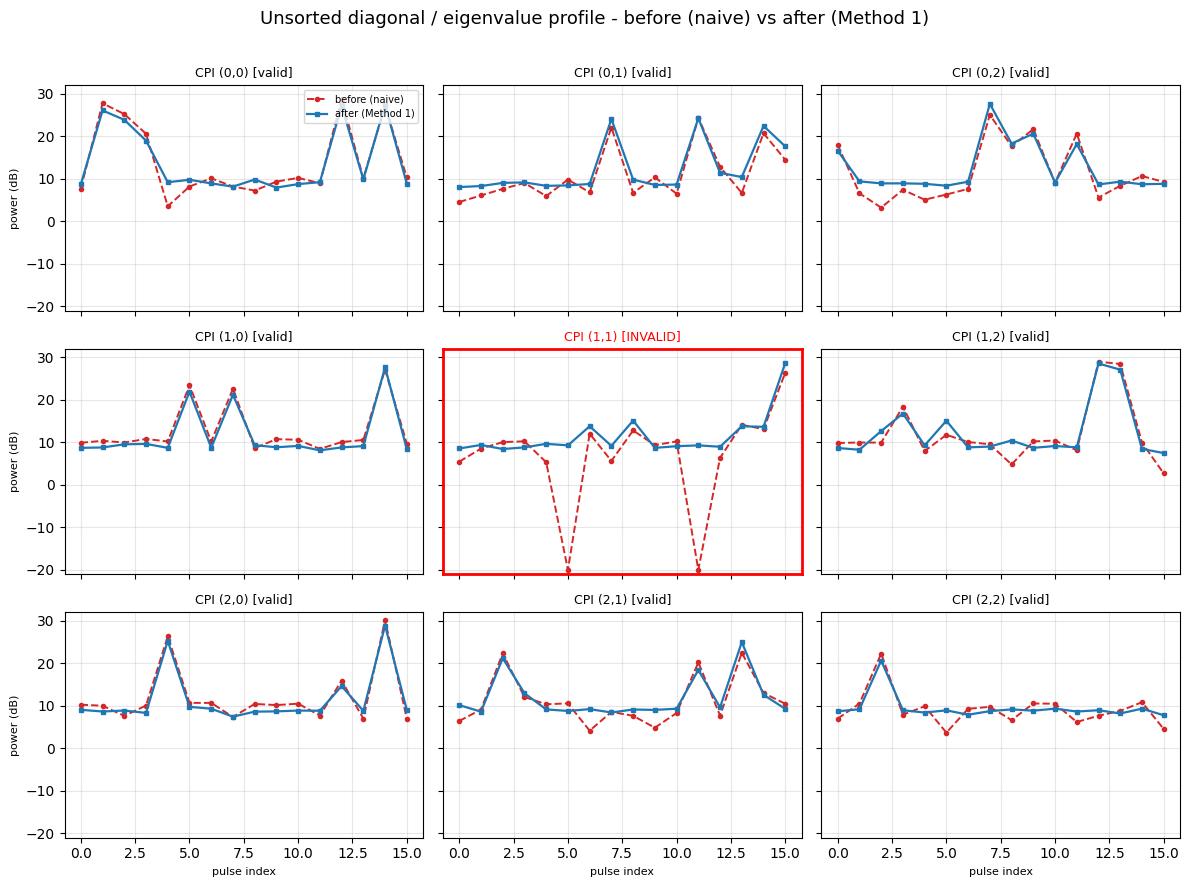

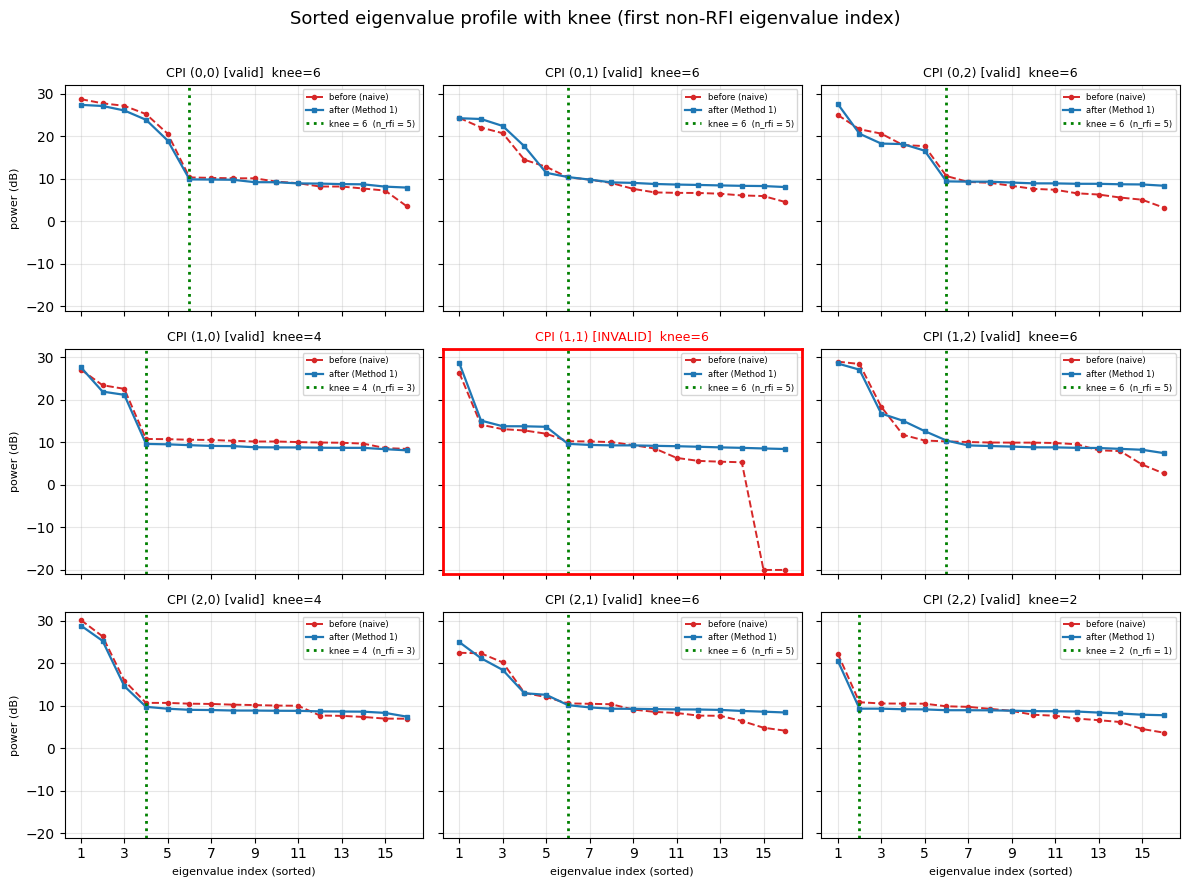

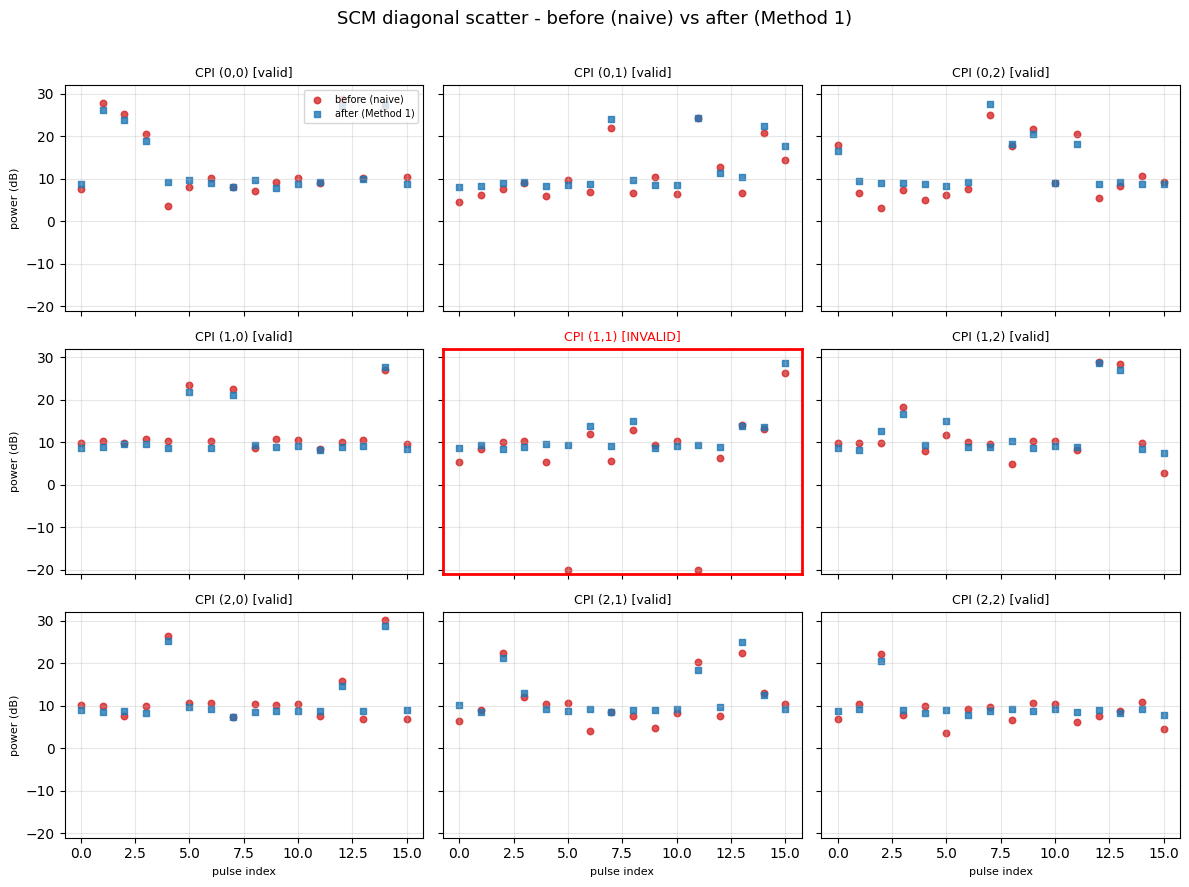

In [8]:
# ---- before/after diagnostics for the 9 CPIs (Method 1) ------------------
# unsorted profile, sorted "mountain" (with knee line), and diagonal scatter.

_all = np.concatenate([np.r_[naive_db[k], robust_db[k]] for k in naive_db])
_ymin, _ymax = np.floor(_all.min()) - 1, np.ceil(_all.max()) + 1

def _cpi_grid(kind, title):
    fig, axes = plt.subplots(GRID, GRID, figsize=(12, 9), sharex=True, sharey=True)
    for bi in range(GRID):
        for bj in range(GRID):
            ax = axes[bi][bj]
            nb, rb = naive_db[(bi, bj)], robust_db[(bi, bj)]
            if kind == "sorted":
                nb, rb = np.sort(nb)[::-1], np.sort(rb)[::-1]
                xs, xlabel = np.arange(1, CPI_ROWS + 1), "eigenvalue index (sorted)"
            else:
                xs, xlabel = np.arange(CPI_ROWS), "pulse index"
            if kind == "scatter":
                ax.scatter(xs, nb, color="C3", s=22, alpha=0.8, label="before (naive)")
                ax.scatter(xs, rb, color="C0", s=22, alpha=0.8, marker="s",
                           label="after (Method 1)")
            else:
                ax.plot(xs, nb, "C3--o", lw=1.4, ms=3, label="before (naive)")
                ax.plot(xs, rb, "C0-s",  lw=1.6, ms=3, label="after (Method 1)")

            # knee line on the INTEGER index of the first non-RFI eigenvalue:
            # n_rfi emitters -> eigenvalues 1..n_rfi are RFI, knee = n_rfi + 1.
            if kind == "sorted":
                k = knee[(bi, bj)]
                ax.axvline(k, color="green", ls=":", lw=2,
                           label=f"knee = {k}  (n_rfi = {n_rfi[(bi, bj)]})")

            invalid = (bi, bj) in invalid_blocks
            ttl = f"CPI ({bi},{bj}) [{cpi_tags[(bi,bj)]}]"
            if kind == "sorted":
                ttl += f"  knee={knee[(bi,bj)]}"
            ax.set_title(ttl, fontsize=9, color="red" if invalid else "black")
            ax.set_ylim(_ymin, _ymax)
            ax.grid(alpha=0.3)
            if invalid:
                for s in ax.spines.values():
                    s.set_edgecolor("red"); s.set_linewidth(2)
            if bi == GRID - 1:
                ax.set_xlabel(xlabel, fontsize=8)
            if bj == 0:
                ax.set_ylabel("power (dB)", fontsize=8)
            if kind == "sorted":
                ax.set_xticks(np.arange(1, CPI_ROWS + 1, 2))
                ax.legend(fontsize=6, loc="upper right")
    if kind != "sorted":
        axes[0][0].legend(fontsize=7, loc="upper right")
    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

_cpi_grid("unsorted",
          "Unsorted diagonal / eigenvalue profile - before (naive) vs after (Method 1)")
_cpi_grid("sorted",
          "Sorted eigenvalue profile with knee (first non-RFI eigenvalue index)")
_cpi_grid("scatter",
          "SCM diagonal scatter - before (naive) vs after (Method 1)")


In [9]:
# ---- ordering / conditioning audit, restricted to VALID pulses ------------
# What matters for the knee is NOT "did every eigenvalue keep its rank" but
# "are the RFI pulses still grouped at the FRONT of the sorted profile".
# Noise-floor rows are i.i.d. draws of the same quantity, so a swap among them
# is estimator noise, not corruption. Everything below is computed on the
# pulses that were valid to begin with (count >= MIN_VALID_SAMPLES); dead /
# sub-gate rows are excluded, since before the repair they carry no
# information and after it they only carry a synthetic bulk value.
#
# Two baselines:
#   naive     mean |x|^2 over ALL bins  (gaps counted as zeros -> gap-biased)
#   available mean |x|^2 over VALID bins only  (what plot_profiles.py computes)
# Method 1 is judged against `available`; `naive` is shown to separate
# gap-bias removal from the mean -> median change.

def available_diagonal(cpi):
    """Gap-excluding mean power per pulse; NaN for rows with no samples."""
    valid = (cpi != 0)
    counts = valid.sum(axis=1)
    p = (np.abs(cpi) ** 2).sum(axis=1)
    return np.where(counts > 0, p / np.maximum(counts, 1), np.nan)

def valid_rows(cpi, min_valid=MIN_VALID_SAMPLES):
    """Pulses that pass the per-row validity gate (the 'initially valid' set)."""
    return np.flatnonzero(np.count_nonzero(cpi, axis=1) >= min_valid)

def front_block(d_db, idx, rfi_idx):
    """Is the RFI set exactly the top-k of the sorted valid profile?

    Returns (ok, n_intruders, margin_db); margin = lowest RFI power minus
    highest non-RFI power, so margin > 0 <=> the block is intact at the front.
    """
    k, rfi = len(rfi_idx), set(rfi_idx.tolist())
    if k == 0 or k == len(idx):
        return True, 0, np.nan
    order = idx[np.argsort(d_db[idx])[::-1]]
    top   = set(order[:k].tolist())
    rest  = [i for i in idx if i not in rfi]
    return top == rfi, len(top - rfi), d_db[sorted(rfi)].min() - d_db[rest].max()

def kendall_tau(a, b):
    n = len(a)
    if n < 2:
        return np.nan, 0
    conc = disc = 0
    for i in range(n):
        for j in range(i + 1, n):
            s = np.sign(a[i] - a[j]) * np.sign(b[i] - b[j])
            conc += s > 0
            disc += s < 0
    return ((conc - disc) / (conc + disc) if conc + disc else np.nan), disc

def eff_rank(lin):
    """Entropy-based effective rank exp(-sum p log p), p = lambda / sum lambda."""
    p = lin / lin.sum()
    p = p[p > 0]
    return float(np.exp(-(p * np.log(p)).sum()))

avail_db = {k: to_db(available_diagonal(block_view(*k))) for k in naive_db}

rows = []
for bi in range(GRID):
    for bj in range(GRID):
        cpi = block_view(bi, bj)
        idx = valid_rows(cpi)
        rfi = np.array(sorted(cpi_rfi_rows[(bi, bj)] & set(idx.tolist())), dtype=int)
        noise = np.array([i for i in idx if i not in set(rfi.tolist())], dtype=int)
        n_db, a_db, r_db = naive_db[(bi, bj)], avail_db[(bi, bj)], robust_db[(bi, bj)]

        tau_rfi,   disc_rfi   = kendall_tau(a_db[rfi],   r_db[rfi])
        tau_noise, disc_noise = kendall_tau(a_db[noise], r_db[noise])
        tau_all,   disc_all   = kendall_tau(a_db[idx],   r_db[idx])

        a_lin, r_lin = 10 ** (a_db[idx] / 10), 10 ** (r_db[idx] / 10)
        rows.append(dict(
            cpi=(bi, bj), tag=cpi_tags[(bi, bj)], n_valid=len(idx), n_rfi=len(rfi),
            front_n=front_block(n_db, idx, rfi),
            front_a=front_block(a_db, idx, rfi),
            front_r=front_block(r_db, idx, rfi),
            tau_rfi=tau_rfi, tau_noise=tau_noise, tau_all=tau_all,
            disc_noise=disc_noise, disc_rfi=disc_rfi, disc_all=disc_all,
            cond_a=a_lin.max() / a_lin.min(), cond_r=r_lin.max() / r_lin.min(),
            er_a=eff_rank(a_lin), er_r=eff_rank(r_lin),
        ))

def _f(front):
    ok, intr, _ = front
    return "YES" if ok else f"no ({intr} in top-k)"

print("RFI block at the FRONT of the sorted profile -- valid pulses only")
print("  (margin = lowest RFI power - highest noise power; > 0 => block intact)\n")
print(f"{'CPI':7s}{'tag':9s}{'#val':>5s}{'#rfi':>5s}   "
      f"{'naive':>15s}{'available':>15s}{'Method 1':>15s}   "
      f"{'margin: naive':>13s}{'avail':>9s}{'Meth1':>9s}")
for r in rows:
    print(f"{str(r['cpi']):7s}{r['tag']:9s}{r['n_valid']:5d}{r['n_rfi']:5d}   "
          f"{_f(r['front_n']):>15s}{_f(r['front_a']):>15s}{_f(r['front_r']):>15s}   "
          f"{r['front_n'][2]:10.2f} dB{r['front_a'][2]:8.2f}{r['front_r'][2]:9.2f}")

print("\nMethod 1 vs available-case baseline, valid pulses only")
print(f"{'CPI':7s}{'tau RFI':>9s}{'tau noise':>10s}{'tau all':>9s}"
      f"{'disc noise/all':>16s}{'cond':>9s}{'eff rank':>10s}")
for r in rows:
    print(f"{str(r['cpi']):7s}{r['tau_rfi']:9.3f}{r['tau_noise']:10.3f}{r['tau_all']:9.3f}"
          f"{str(r['disc_noise']) + '/' + str(r['disc_all']):>16s}"
          f"{100 * (r['cond_r'] / r['cond_a'] - 1):8.1f}%"
          f"{100 * (r['er_r'] / r['er_a'] - 1):9.1f}%")

fn = sum(r['front_n'][0] for r in rows)
fa = sum(r['front_a'][0] for r in rows)
fr = sum(r['front_r'][0] for r in rows)
t_rfi   = np.array([r['tau_rfi']   for r in rows], dtype=float)
t_noise = np.array([r['tau_noise'] for r in rows], dtype=float)
dc = [100 * (r['cond_r'] / r['cond_a'] - 1) for r in rows]
de = [100 * (r['er_r']   / r['er_a']   - 1) for r in rows]
print(f"\nRFI block intact at the front: naive {fn}/9, available {fa}/9, Method 1 {fr}/9")
print(f"mean separation margin:        naive {np.nanmean([r['front_n'][2] for r in rows]):.2f} dB, "
      f"available {np.nanmean([r['front_a'][2] for r in rows]):.2f} dB, "
      f"Method 1 {np.nanmean([r['front_r'][2] for r in rows]):.2f} dB")
print(f"tau inside the RFI block:  mean {np.nanmean(t_rfi):+.3f}  min {np.nanmin(t_rfi):+.3f}")
print(f"tau inside the noise floor: mean {np.nanmean(t_noise):+.3f}  min {np.nanmin(t_noise):+.3f}")
d_all   = sum(r['disc_all']   for r in rows)
d_noise = sum(r['disc_noise'] for r in rows)
d_rfi   = sum(r['disc_rfi']   for r in rows)
print(f"discordant pairs (valid only): {d_all} total = {d_noise} noise-noise "
      f"+ {d_rfi} inside the RFI block + {d_all - d_noise - d_rfi} crossing the boundary")
print(f"condition number: {min(dc):+.1f}% .. {max(dc):+.1f}%")
print(f"effective rank:   {min(de):+.1f}% .. {max(de):+.1f}%")

RFI block at the FRONT of the sorted profile -- valid pulses only
  (margin = lowest RFI power - highest noise power; > 0 => block intact)

CPI    tag       #val #rfi             naive      available       Method 1   margin: naive    avail    Meth1
(0, 0) valid       16    5               YES            YES            YES        10.25 dB    9.28     9.13
(0, 1) valid       16    5               YES            YES            YES         2.48 dB    1.81     1.00
(0, 2) valid       16    5               YES            YES            YES         7.03 dB    7.24     7.22
(1, 0) valid       16    3               YES            YES            YES        11.79 dB   11.63    11.55
(1, 1) INVALID     14    5               YES            YES            YES         1.79 dB    4.41     4.00
(1, 2) valid       16    5   no (1 in top-k)            YES            YES        -0.49 dB    3.53     2.22
(2, 0) valid       16    3               YES            YES            YES         5.24 dB    5.37     

# Method 1 — Robust Available-Case Diagonal

## What it does

The per-pulse SCM diagonal is repaired so a gap-damaged CPI stops being skipped, without ever
filling a missing sample from another pulse.

```
for each pulse row i:
    if row i has >= MIN_ROBUST (4) valid samples:
        d[i] = median(|x_i,valid|^2)     # own samples only, robust to spikes
    else:                                # fully dead / too sparse
        d[i] = bulk                      # bulk = median of the rows that do have data
d = d + LOAD_FRAC * bulk                 # 3% loading -> every entry strictly > 0
```

Three properties follow by construction:

- **No cross-pulse imputation.** A gap is never filled from the pulse above, below, or from a
  neighbouring CPI. Nothing can fabricate an off-diagonal correlation, so no phantom RFI is created.
- **Dead pulses become independent noise dimensions.** They carry diagonal power only.
- **Full rank.** All 16 eigenvalues are non-zero (verified 16/16 on the invalid CPI), versus rank
  collapse when zeros are left in — condition number ~3x10^18 before, ~10^2 after.

Because the SCM here is strongly diagonal-dominant (off-diagonal energy ~3% of the diagonal), the
eigenvalue profile *is* the sorted diagonal, so the full SCM is never formed.

## Does it corrupt anything?

Measured on the 3x3 CPI grid, **valid rows only** (dead rows excluded), against a gap-excluding
mean baseline — i.e. what the existing `plot_profiles.py` diagonal computes.

| Property | Result | Corrupted? |
|---|---|---|
| Knee position (label) | Derived from generator metadata, not from the data | **No** |
| Knee detectability | naive 4/9, Method 1 4/9; mean separation margin (valid pulses) 5.67 -> 5.97 dB | **No** |
| **RFI block at the front** (valid pulses) | **9/9 CPIs intact** (naive baseline: 8/9); 0 of 122 discordant pairs cross the RFI/noise boundary | **No — see below** |
| Ordering within the RFI block | Kendall tau mean +0.900 (min +0.600), 4 discordant pairs | Marginal |
| Ordering within the noise floor | Kendall tau mean +0.602, 118 discordant pairs | Yes, and it doesn't matter |
| Relative ordering, all valid pulses pooled | Kendall tau mean +0.771 (min +0.550), 122 discordant pairs | Misleading — see below |
| Condition number (valid idx) | −2.9% … **+25.9%** | Yes, modest |
| Effective rank (valid idx) | −3.7% … **+2.2%** | Marginal |
| median/max diagonal ratio | −6.3% … **+14.3%** | Yes, modest |
| Feature **shape** | RMSE 0.298 dB (max 0.393), maxDev 1.112 dB, corr **>= 0.99884** | **No** |

### Ordering: only the RFI/noise split is a real requirement

A pooled Kendall tau over all 16 eigenvalues answers the wrong question. Noise-floor pulses are
i.i.d. draws of the same quantity, so their mutual order is estimator noise, not information — two
of them swapping carries no meaning, and a metric that penalises it will condemn any change of
estimator. What the knee actually depends on is that the contaminated pulses stay **grouped at the
front** of the sorted profile. Everything below is measured on the **initially valid** pulses only
(`count >= MIN_VALID_SAMPLES`); dead and sub-gate rows are excluded, since they hold no information
before the repair and only a synthetic bulk value after it.

Scored that way (audit cell in `gaps.ipynb`), on the 3x3 grid:

| | naive | available-case | Method 1 |
|---|---|---|---|
| CPIs with the RFI set exactly = top-k | 8/9 | 9/9 | **9/9** |
| Mean separation margin (lowest RFI − highest noise) | 5.67 dB | 6.40 dB | **5.97 dB** |

The one naive failure is CPI (1,2), where the gap bias pushes a noise pulse above an RFI pulse
(margin **−0.49 dB**); Method 1 restores the block (**+2.22 dB**). Of the 122 discordant pairs
against the available-case baseline, **118 are noise-noise, 4 are inside the RFI block, and 0 cross
the boundary** — the split the knee is defined by is untouched in every CPI. Within the RFI block
tau is +0.900; all four inversions are between emitters within 3 dB of JNR (three of them within
1 dB) separated by <= 0.9 dB under either estimator, i.e. pairs whose order was never resolvable.
Within the noise floor tau is +0.602, which is the part that is free to move.

The pooled ordering does change, for two reasons. Neither touches the RFI/noise split, and both are
corrections rather than damage.

1. **Estimator change (mean -> median).** A constant −1.3 dB offset (theory for exponential
   `|CN|^2`: −1.59 dB). Pure DC — it cancels in any shape-normalised feature.
2. **Gap-bias removal.** The naive diagonal divides by all 250 bins regardless of how many are
   valid, under-reporting each gapped row by ~`10log10(valid_fraction)` dB. Confirmed: correlation
   **+0.944**, fit slope **0.991** between the dB change and `-10log10(valid_fraction)`.

Against ungapped ground truth the reordering moves *toward* truth (rank agreement +0.775 -> +0.904;
shape RMSE 1.809 -> 0.536 dB). The naive ordering was wrong; preserving it would preserve the bias.

If bit-exact preservation is ever required, keeping the gap-excluding **mean** for live rows and
filling only dead rows gives tau = 1.000, zero discordant pairs, and identical
condition number / effective rank / median-max — verified — at the cost of outlier robustness
(one 60 dB spike shifts a row +27.8 dB under plain mean vs +0.13 dB under 1% trimming).

## Impact on neural-network accuracy

**Low risk for a shape-based model.** The normalised sorted profile is preserved to
corr >= 0.99884 and RMSE ~0.3 dB across all 8 valid CPIs — far below CPI-to-CPI variation. Knee
detectability is unchanged (4/9 both) and the separation margin slightly improves.

**No "repaired CPI" signature.** Checked explicitly, since a synthetic artifact would leak the
label. Tail (noise-floor) standard deviation is 0.501 dB under Method 1 vs 0.363 dB baseline —
*more* variable, not flatter, because the median is a noisier estimator. The repaired CPI's tail
std of **0.358 dB** sits inside the valid range **0.302–0.689 dB**, so it is not separable from a
naturally clean CPI on that basis.

### Three real caveats

1. **The repaired CPI does not recover its true profile.** Shape RMSE vs truth is **4.1 dB**
   (valid CPIs: 0.4–1.5 dB) and the empirical knee lands at 2 against a label of 6. Information in
   fully wiped pulses is gone and cannot be reconstructed from other pulses without violating row
   independence. Carry a confidence value (`valid_fraction`, or min valid samples/row) so the model
   can down-weight these rather than treat them as clean.

2. **Wiped RFI pulses change the label.** If a gap destroys a pulse that was carrying RFI, that
   pulse is no longer contaminated and `n_rfi` must decrease. Observed on CPI (1,1): 6 emitters
   injected, row 11 wiped, effective `n_rfi = 5`, knee = 6. A label taken from the injection
   metadata alone would be wrong, and the model would be trained against an unlearnable target.

3. **Absolute power shifts by −1.3 dB.** Harmless for shape-normalised inputs; if the network
   consumes unnormalised dB eigenvalues, either normalise or use the mean estimator, which is also
   the more accurate one (0.260 dB vs 0.536 dB shape error against truth).

## Parameters

| Name | Value | Notes |
|---|---|---|
| `MIN_ROBUST` | 4 | Min valid samples for a per-row estimate; below this -> bulk |
| `LOAD_FRAC` | 0.03 | Diagonal loading as a fraction of bulk power |
| `MIN_VALID_SAMPLES` | `2 * TOTAL_PULSES` = 32 | CPI validity gate (Reed-Mallett-Brennan ~2N) |

`LOAD_FRAC` is arguably redundant in the diagonal-only formulation — every entry is already
positive once dead rows take the bulk value — and it slightly compresses the condition number.
Set it to 0 if exact conditioning matters more than a guaranteed positive margin.